# Introduction to Machine Learning — Class 4
## Logistic Regression, Decision Boundary & Regularization

**Input dataset:** `adult_classification_v1.csv`  

---

### Learning goals
- Formulate a binary classification problem
- Understand logistic regression as a probabilistic model
- Interpret the sigmoid function and decision boundary
- Analyse overfitting in classification
- Apply regularization to control model complexity

> **Key idea:** Classification is about decision-making under uncertainty.

<div style="margin-left: 2em; font-size: 0.9em; font-style: italic;">
An AI language model (ChatGPT by OpenAI) was used to support the creation of practical class materials. 
All arguments, outputs, and final wording were critically reviewed, edited, and validated by the author 
prior to use with students.
</div>

## 0. Data context

This session uses a **classification-oriented version** of the Adult dataset.

- Target variable: `income` (binary)
- Numerical features only
- Categorical variables were encoded beforehand

The dataset reflects one modelling choice, not the only possible one.


In [4]:
DATA_PATH = "adult_classification_v1.csv"


## 1. Imports


In [5]:
# TODO: import required libraries
# numpy, pandas, matplotlib
# sklearn: LogisticRegression, train_test_split, accuracy_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
 

In [6]:
# Auto-check
import importlib
_required = ["numpy", "pandas", "sklearn", "matplotlib"]
missing = [m for m in _required if importlib.util.find_spec(m) is None]
assert not missing, f"Missing packages: {missing}"
print("Auto-check passed.")


Auto-check passed.


## 2. Load and inspect the dataset

### Tasks
- Load the dataset into `df`
- Inspect class balance

**Reflection**
- Is the dataset balanced?
- What does the target represent?

In [7]:
# TODO: load dataset
df = pd.read_csv(DATA_PATH)
df.head()
# df.columns



,age,capital-gain,capital-loss,educational-num,fnlwgt,gender=Female,gender=Male,hours-per-week,marital-status=Divorced,marital-status=Married-AF-spouse,...,relationship=Unmarried,relationship=Wife,workclass=Federal-gov,workclass=Local-gov,workclass=Private,workclass=Self-emp-inc,workclass=Self-emp-not-inc,workclass=State-gov,workclass=Without-pay,income
0,67,0,0,9,154035,0,1,32,0,0,...,0,0,0,0,1,0,0,0,0,0
1,48,0,0,13,146497,1,0,50,0,0,...,0,1,0,0,1,0,0,0,0,1
2,24,0,0,7,478457,1,0,30,0,0,...,0,0,0,0,1,0,0,0,0,0
3,48,99999,0,15,93449,0,1,40,0,0,...,0,0,0,1,0,0,0,0,0,1
4,24,0,0,13,86745,1,0,40,0,0,...,0,0,0,0,1,0,0,0,0,0


In [8]:
#count number of income = 1
df['income'].value_counts()

income
0    34014
1    11208
Name: count, dtype: int64

In [9]:
# Auto-check
import pandas as pd
assert "df" in globals(), "df not found"
assert "income" in df.columns, "Target column 'income' not found"
print("Auto-check passed.")


Auto-check passed.


## 3. Define X and y

### Task
- Separate features and target
- Split into training and validation sets


In [10]:
# TODO: define X and y and split into train and test sets
X = df.drop(columns=['income'])
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
y_test.value_counts(normalize=True)

income
0    0.752128
1    0.247872
Name: proportion, dtype: float64

In [12]:
y_train.value_counts(normalize=True)

income
0    0.752163
1    0.247837
Name: proportion, dtype: float64

## 4. Logistic regression model

### Task
- Fit logistic regression
- Predict probabilities and classes

**Reflection**
- What does the model output represent?


In [13]:
# TODO: fit logistic regression

model = LogisticRegression(max_iter=10000, verbose=True)
model.fit(X_train, y_train)

#y_probs = model.predict_proba(X_test)[:, 1]
#y_pred = model.predict(X_test)

#y_pred = model.predict(X_test)
#accuracy = accuracy_score(y_test, y_pred)
#print(f"Test set accuracy: {accuracy:.4f}")

C:\Users\dinis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.4min finished


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


### 4b - Scaling

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

scaler = StandardScaler()
lgreg = LogisticRegression(max_iter=10000)
model = make_pipeline(scaler, lgreg, verbose=True)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
y_prob

# summary of model coefficients

print("Model coefficients:")
print(model.named_steps['logisticregression'].coef_)

#accuracy = accuracy_score(y_test, y_pred)
#print(f"Test set accuracy: {accuracy:.4f}")


[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.1s
[Pipeline]  (step 2 of 2) Processing logisticregression, total=   0.2s
Model coefficients:
[[ 0.33759199  2.34610086  0.24839007  0.72281333  0.07545712 -0.16962519
   0.16962519  0.35481144 -0.26502683  0.04800021  0.76666426 -0.05335229
  -0.53171243 -0.12868428 -0.09331597  0.03908204 -0.03107636  0.01273009
  -0.0153775   0.01424483  0.0063961  -0.011265    0.03971396  0.03699185
  -0.07405026 -0.04176631  0.02243599 -0.0068372  -0.05422741  0.0485604
  -0.0129758   0.00281311  0.01688707  0.2458174  -0.1874003  -0.15285023
  -0.09677807 -0.27573281 -0.17885928  0.17963     0.06208597  0.06952683
   0.08948237 -0.02690356 -0.05003036  0.04930531 -0.04245282  0.01718992
   0.02163104 -0.0450268   0.16500347 -0.14086203 -0.25076956  0.0491311
   0.22752311  0.10808294 -0.01148645  0.03953069  0.05128311 -0.12112968
  -0.04506483 -0.00763291]]


In [15]:
model.predict_proba(X_test)

array([[9.59286260e-01, 4.07137395e-02],
       [2.21782467e-01, 7.78217533e-01],
       [9.63218920e-01, 3.67810795e-02],
       ...,
       [8.73993834e-01, 1.26006166e-01],
       [3.50830476e-14, 1.00000000e+00],
       [6.73549914e-01, 3.26450086e-01]])

In [16]:
scaler.mean_
scaler.scale_

array([1.32460855e+01, 7.61227034e+03, 3.99606947e+02, 2.54799190e+00,
       1.05657265e+05, 4.68224641e-01, 4.68224641e-01, 1.20254444e+01,
       3.44974648e-01, 2.57481032e-02, 4.98893922e-01, 1.09240944e-01,
       4.67568583e-01, 1.73430757e-01, 1.66471186e-01, 5.74980172e-02,
       4.98154542e-02, 5.48077192e-02, 5.82098839e-02, 4.89801959e-02,
       6.51055106e-02, 5.65347307e-02, 4.57861221e-02, 4.66791099e-02,
       1.36684045e-01, 1.62985656e-01, 7.89641248e-02, 6.20877301e-02,
       4.57861221e-02, 2.78838706e-01, 3.28190480e-01, 1.89529736e-02,
       3.39229629e-01, 3.39707895e-01, 1.78720232e-01, 2.07730405e-01,
       2.48635357e-01, 3.08552276e-01, 7.11353356e-02, 3.38479829e-01,
       1.45152841e-01, 3.23330541e-01, 1.75509401e-01, 2.20052611e-01,
       9.95300479e-02, 1.68338265e-01, 2.89987968e-01, 8.70112212e-02,
       3.46476404e-01, 4.92484250e-01, 4.37508525e-01, 1.71928492e-01,
       3.53691574e-01, 3.06532584e-01, 2.10253643e-01, 1.73804019e-01,
      

In [17]:
all(y_pred == (y_prob >= 0.5))

True

## 5. Sigmoid and decision boundary

### Task
- Plot sigmoid function
- Reduce data to 2D (PCA) and visualise decision boundary

**Reflection**
- What happens near probability 0.5?


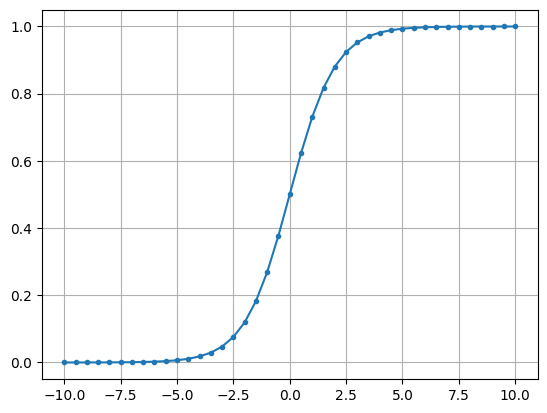

In [18]:
# TODO: sigmoid and decision boundary plots
t = np.linspace(-10, 10, 41)
sig = 1 / (1 + np.exp(-t))

plt.plot(t, sig, '.-')
plt.grid(True)

In [19]:
# - Reduce data to 2D (PCA) and visualise decision boundary
from sklearn.decomposition import PCA

scaler2 = StandardScaler()
pca = PCA(n_components=2)
pca_pipeline = make_pipeline(scaler2, pca, verbose=True)
pca_pipeline.fit(X_train)

all(scaler2.scale_ == scaler.scale_) and all(scaler2.mean_ == scaler.mean_)

[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.1s
[Pipeline] ............... (step 2 of 2) Processing pca, total=   0.0s


True

<Axes: xlabel='pc0', ylabel='pc1'>

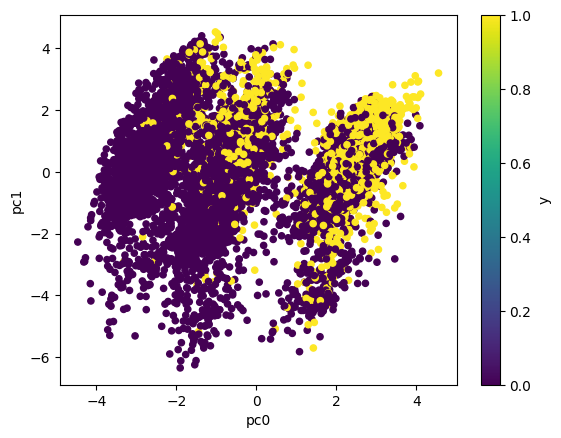

In [20]:
x_pca = pca_pipeline.transform(X_test)
df_val = pd.DataFrame({'pc0': x_pca[:, 0], 'pc1': x_pca[:, 1], 'y': y_test, 'y_pred': y_pred, 'y_prob': y_prob})

df_val.plot(x='pc0', y='pc1', kind='scatter', c='y', colormap='viridis')

## 6. Classification performance

### Task
- Compute accuracy

**Reflection**
- Is accuracy always meaningful?


In [21]:
# TODO: compute accuracy
accuracy_score(y_test, y_pred), precision_score(y_test, y_pred)


(0.845771144278607, 0.7280560043080236)

## 7. Overfitting and regularization strength

### Task
- Compare models with different C values

**Reflection**
- How does C affect the decision boundary?


In [22]:
# TODO: try different C values

for C in [0.01, 0.1, 1, 10, 100]:
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000, C=C), verbose=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    print(f"C={C}: Accuracy={acc:.4f}, Precision={prec:.4f}")


[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.1s
[Pipeline]  (step 2 of 2) Processing logisticregression, total=   0.1s
C=0.01: Accuracy=0.8452, Precision=0.7288
[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.1s
[Pipeline]  (step 2 of 2) Processing logisticregression, total=   0.2s
C=0.1: Accuracy=0.8456, Precision=0.7275
[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.1s
[Pipeline]  (step 2 of 2) Processing logisticregression, total=   0.2s
C=1: Accuracy=0.8458, Precision=0.7281
[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.0s
[Pipeline]  (step 2 of 2) Processing logisticregression, total=   0.2s
C=10: Accuracy=0.8459, Precision=0.7282
[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.0s
[Pipeline]  (step 2 of 2) Processing logisticregression, total=   0.2s
C=100: Accuracy=0.8459, Precision=0.7282


## 8. L1 vs L2 regularization

### Task
- Compare L1 and L2 penalties

**Reflection**
- Why do some coefficients become zero?


In [28]:
# TODO: L1 vs L2 comparison

for penalty in ['l1', 'l2']:
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000, C=1, penalty=penalty, solver='saga'), verbose=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    print(f"Penalty={penalty}: Accuracy={acc:.4f}, Precision={prec:.4f}")
    print(f"Model coefficients for {penalty} penalty:")
    print(model.named_steps['logisticregression'].coef_)
    # mse
    print(f"Model MSE for {penalty} penalty:")
    print(np.mean((y_test - model.predict_proba(X_test)[:, 1]) ** 2))
    
    # selected variables of Lasso (L1) regression
    if penalty == 'l1':
        print("Selected variables (non-zero coefficients):")
        selected = np.where(model.named_steps['logisticregression'].coef_[0] != 0)[0]
        print(X.columns[selected])
    


[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.1s
[Pipeline]  (step 2 of 2) Processing logisticregression, total=  31.4s
Penalty=l1: Accuracy=0.8457, Precision=0.7277
Model coefficients for l1 penalty:
[[ 3.37247166e-01  2.35431520e+00  2.48349803e-01  7.23934931e-01
   7.50284104e-02 -1.68405145e-01  1.68405145e-01  3.54864389e-01
  -7.22598059e-02  6.11598530e-02  1.02482362e+00  7.22559786e-03
  -2.70403043e-01 -3.10660013e-02  0.00000000e+00  3.31490378e-02
  -3.56437101e-02  7.06653203e-03 -2.06140710e-02  9.14384816e-03
   0.00000000e+00 -1.64724821e-02  3.49297163e-02  3.19258000e-02
  -8.67493541e-02 -5.75079780e-02  1.46473128e-02 -1.25515763e-02
  -5.82800907e-02  2.06917305e-02 -2.89440282e-02  1.68318444e-03
   0.00000000e+00  2.28565027e-01 -1.96731329e-01 -1.61887250e-01
  -1.08863670e-01 -2.90495628e-01 -1.84550233e-01  1.61978461e-01
   5.46745717e-02  5.30658766e-02  8.04750554e-02 -3.75137160e-02
  -5.59751228e-02  3.79416422e-02 -6.02725864e-02  

## 9. Critical reflection

- How does logistic regression make decisions?
- What assumptions does it make?
- What are the risks of using it on human data?


### Reflection

#### 1. How logistic regression makes decisions

Logistic regression computes a weighted sum of the input features and converts it into a probability using the sigmoid function.

P(y=1|x) = 1 / (1 + e^{-z})

The model then applies a threshold (commonly 0.5):
- p ≥ 0.5 → class 1
- p < 0.5 → class 0

---

#### 2. Assumptions

- The **log-odds are linearly related** to the input features.
- **Observations are independent**.
- There is **low multicollinearity** between predictors.
- Features are **correctly encoded** and there is sufficient data for each class.

---

#### 3. Risks when using human data

- **Bias in historical data** can lead to discriminatory predictions.
- **Proxy variables** (e.g., postcode representing socioeconomic status) may introduce indirect bias.
- **Incorrect encoding of categories** can create artificial relationships.
- Model decisions may **unfairly impact certain demographic groups**.